In [2]:
from google.colab import drive

drive.mount('/content/drive')

# 認証が完了すると、「drive/My Drive」以下にgoogle driveのルートがマウントされる。

Mounted at /content/drive


In [3]:
import pandas as pd

# Google Drive path (for Colab)
file_path = "/content/drive/MyDrive/Data/tsa-analysis-Japan/data/JTA_TSA_2023.xlsx"
sheet_name = "Table6b"

df_raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

# 上から10行確認
df_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,Table 6b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Tourism domestic supply and internal tourism c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,第６b表 国内観光供給及び内部観光消費（日本独自基準）,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,(2023年 CY2023),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,（単位：10億円 Billion Yen）
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tourism industries 観光産業,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# GVA

In [4]:
# 列名を抽出
col_names = df_raw.iloc[6].tolist()

# データ部分（B列〜U列）
df = df_raw.iloc[:, 2:21].copy()
df.columns = col_names[2:21]

# GVA
gva = df.iloc[46]
gva.index = gva.index.str.replace("\n", "", regex=False)

# 観光比率列（最後の列）
ratio = df.iloc[:, -1].copy()

# 数値化
ratio_num = pd.to_numeric(ratio, errors="coerce")

# gvaの項目を手動で
mapping = {
    "宿泊業": 11,
    "宿泊業（1.bを除く）": 12,
    "別荘（帰属家賃）": 13,
    "飲食業": 14,
    "鉄道旅客輸送": 15,
    "道路旅客輸送": 16,
    "水運": 17,
    "航空輸送": 18,
    "その他の運輸業(**)": 19,
    "スポーツ・娯楽業": 22,
}

# mappingした部分（観光比率）を抽出
ratio_selected = ratio_num.loc[list(mapping.values())].copy()
ratio_selected.index = list(mapping.keys())

# mappingした部分（観光比率）を抽出
gva_selected = gva.loc[mapping.keys()]

# DataFrame
df_final = pd.DataFrame({
    "GVA": pd.to_numeric(gva_selected, errors="coerce"),
    "Tourism Ratio (%)": pd.to_numeric(ratio_selected, errors="coerce")
})

df_final.sort_values("GVA", ascending=False)

,GVA,Tourism Ratio (%)
宿泊業,3657,86.0
宿泊業（1.bを除く）,3218,85.1
鉄道旅客輸送,1462,47.8
飲食業,1369,19.1
スポーツ・娯楽業,914,13.9
その他の運輸業(**),866,23.8
航空輸送,679,75.7
別荘（帰属家賃）,440,100.0
道路旅客輸送,362,16.5
水運,24,85.5


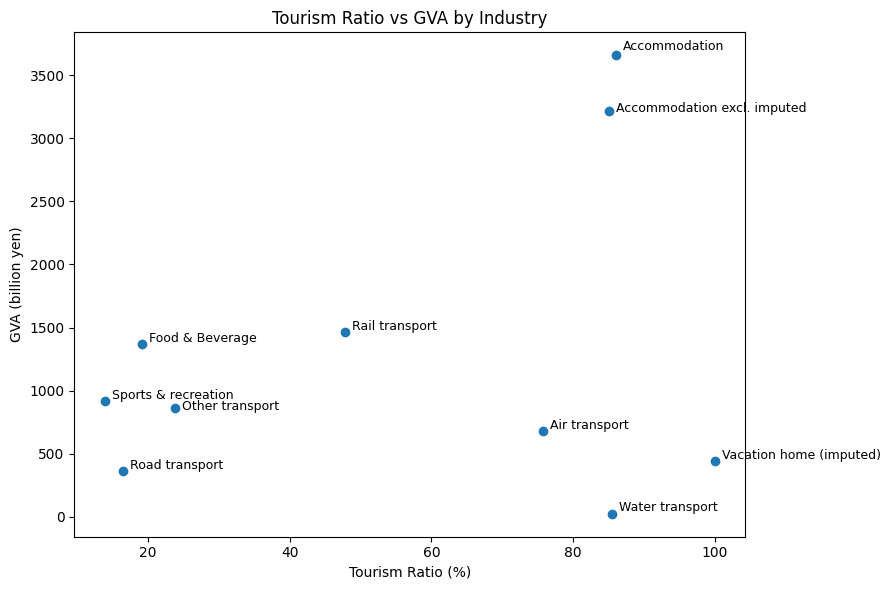

In [6]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "DejaVu Sans"

labels_en = {
    "宿泊業": "Accommodation",
    "宿泊業（1.bを除く）": "Accommodation excl. imputed",
    "別荘（帰属家賃）": "Vacation home (imputed)",
    "飲食業": "Food & Beverage",
    "鉄道旅客輸送": "Rail transport",
    "道路旅客輸送": "Road transport",
    "水運": "Water transport",
    "航空輸送": "Air transport",
    "その他の運輸業(**)": "Other transport",
    "スポーツ・娯楽業": "Sports & recreation",
}

df_plot = df_final.copy()
df_plot["label_en"] = [labels_en[i] for i in df_plot.index]

# ラベルの微調整用オフセット
offsets = {
    "Accommodation": (1.0, 40),
    "Accommodation excl. imputed": (1.0, -10),
    "Vacation home (imputed)": (1.0, 20),
    "Food & Beverage": (1.0, 20),
    "Rail transport": (1.0, 20),
    "Road transport": (1.0, 20),
    "Water transport": (1.0, 20),
    "Air transport": (1.0, 20),
    "Other transport": (1.0, -20),
    "Sports & recreation": (1.0, 20),
}

plt.figure(figsize=(9, 6))
plt.scatter(df_plot["Tourism Ratio (%)"], df_plot["GVA"])

for _, row in df_plot.iterrows():
    label = row["label_en"]
    dx, dy = offsets.get(label, (1.0, 10))
    plt.text(
        row["Tourism Ratio (%)"] + dx,
        row["GVA"] + dy,
        label,
        fontsize=9
    )

plt.title("Tourism Ratio vs GVA by Industry")
plt.xlabel("Tourism Ratio (%)")
plt.ylabel("GVA (billion yen)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Data/tsa-analysis-Japan/tourism_ratio_vs_gva.png", dpi=300)
plt.show()

In [7]:
df_final.corr()

,GVA,Tourism Ratio (%)
GVA,1.000000,0.271137
Tourism Ratio (%),0.271137,1.000000


# GDP

In [20]:
# 観光GDP（各産業）
df_final["Tourism GDP"] = df_final["GVA"] * df_final["Tourism Ratio (%)"] / 100

# 合計（これが観光GDP）
tourism_gdp_total = df_final["Tourism GDP"].sum()

df_final

,GVA,Tourism Ratio (%),Tourism GDP
宿泊業,3657,86.0,3145.020
宿泊業（1.bを除く）,3218,85.1,2738.518
別荘（帰属家賃）,440,100.0,440.000
飲食業,1369,19.1,261.479
鉄道旅客輸送,1462,47.8,698.836
道路旅客輸送,362,16.5,59.730
水運,24,85.5,20.520
航空輸送,679,75.7,514.003
その他の運輸業(**),866,23.8,206.108
スポーツ・娯楽業,914,13.9,127.046


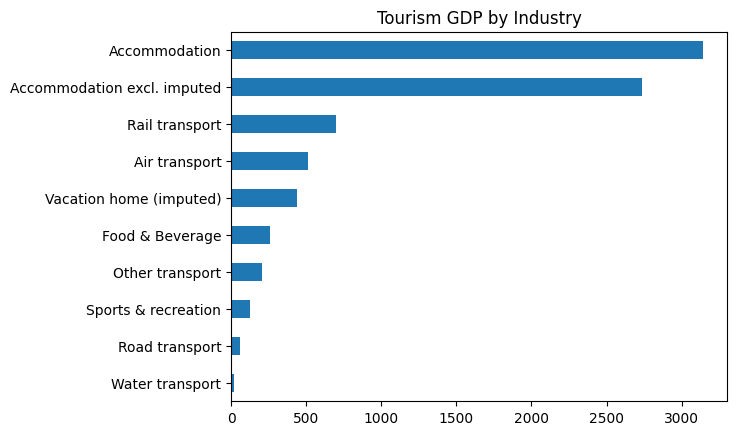

In [24]:
df_final.index = [labels_en.get(i, i) for i in df_final.index]

df_final["Tourism GDP"].sort_values().plot(kind="barh")
plt.title("Tourism GDP by Industry")
plt.savefig("/content/drive/MyDrive/Data/tsa-analysis-Japan/tourism_gdp_by_industry.png", dpi=300)
plt.show()